### Instructions

1. Plug in the `model_path`
2. From `Run` menu, select `Restart Kernel and Run All Cells`
3. From `View` menu, select `Collapse All Code`

In [1]:
model_path = '/data00/projects/geoscan_v2/scripts/L1/model_images-GEONC.json'


In [2]:
import os, glob, re, sys, json, copy  

import nipype.interfaces.io as nio           
import nipype.interfaces.spm as spm    
import nipype.interfaces.matlab as mlab     
import nipype.pipeline.engine as pe 
import nipype.interfaces.utility as util

import pandas as pd
import numpy as np
import scipy as sp
import scipy.io as sio

from nilearn import plotting

In [3]:
def ensure_list(obj):
    if type(obj) is not list:
        return [obj]
    else:
        return obj

def copy_from_template(target, template):
    for key, item in template.items():
        if key not in target.keys():
            target[key] = copy.deepcopy(template[key])
        elif type(item) is dict:
            copy_from_template(target[key], template[key])

In [4]:
with open(model_path, 'r') as f:
    model = json.load(f)

for template_path in ensure_list(model.get("Template", [])):
    with open(template_path, 'r') as f:
        template = json.load(f)
    copy_from_template(model, template)
    
env = model['Environment']
job_name = 'task-{}_model-{}'.format(model['Info']['task'], model['Info']['model'])

In [5]:
env

{'job_path': 'models',
 'spm_path': '/data00/tools/spm12mega',
 'fsl_path': '/data00/tools/fsl',
 'data_path': '/data00/projects/geoscan_v2',
 'output_path': '/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype',
 'working_path': '/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/working/nipype'}

In [6]:
mlab.MatlabCommand.set_default_matlab_cmd("matlab -nodesktop -nosplash")
mlab.MatlabCommand.set_default_paths(env["spm_path"])

In [7]:
con_df = []
print("Aggregating contrast files...")

for sub_folder in glob.glob(os.path.join(env['output_path'], job_name, 'sub-*')):
    
    if not os.path.isdir(sub_folder):
        continue
    
    sub = os.path.basename(sub_folder)
    
    spm_file = os.path.join(sub_folder, 'SPM.mat')
    if not os.path.exists(spm_file):
        continue
    
    spm_mat = sio.loadmat(spm_file, 
               squeeze_me=True, struct_as_record=False)
    
    for n, con in enumerate(spm_mat['SPM'].xCon, start=1):
        con_file = os.path.join(sub_folder, f"con_{n:04d}.nii")
        if os.path.exists(con_file):
            con_df.append({'sub': sub,
                          'con': con.name,
                          'path': con_file})
        
con_df = pd.DataFrame(con_df)
con_df.to_csv(os.path.join(env['output_path'], job_name, 'contrasts.csv'), index=False)
con_df.pivot_table(index='con', values='sub', aggfunc='count')

Aggregating contrast files...


,sub
con,
personal_nonsmoke,11
personal_smoke,11
rating,11
retailSmokeFamiliar_v_retailNonsmokeFamiliar,11
retailSmoke_v_retailNonsmoke,11
retail_nonsmoke_familiar,11
retail_nonsmoke_unfamiliar,11
retail_smoke_familiar,11
retail_smoke_unfamiliar,11


In [8]:
def get_contrast_files(contrast_name, contrast_df):
    return contrast_df.query(f'con == "{contrast_name}"').path.tolist()

In [9]:
l2analysis_path = os.path.join(env['output_path'], job_name, "l2analysis")

In [ ]:
l2analysis = pe.Workflow(base_dir=os.path.join(env['working_path'], job_name), name='l2analysis')

infosource = pe.Node(util.IdentityInterface(fields=['contrast_name']),
                  name="infosource")
infosource.iterables = ('contrast_name', con_df.con.unique().tolist())

getcontrastfiles = pe.Node(util.Function(input_names=['contrast_name', 'contrast_df'],
                                        output_names=['contrast_files'],
                                        function=get_contrast_files),
                    name='getcontrastfiles')
getcontrastfiles.inputs.contrast_df = con_df

# One Sample T-Test Design - creates one sample T-Test Design
onesamplettestdes = pe.Node(spm.OneSampleTTestDesign(),
                         name="onesampttestdes")

# EstimateModel - estimate the parameters of the model
level2estimate = pe.Node(spm.EstimateModel(estimation_method={'Classical': 1}),
                      name="level2estimate")

# EstimateContrast - estimates simple group contrast
level2conestimate = pe.Node(spm.EstimateContrast(group_contrast=True), 
                            name="level2conestimate")
cont = ['Group', 'T', ['mean'], [1]]
level2conestimate.inputs.contrasts = [cont]

# Datasink - creates output folder for important outputs
datasink = pe.Node(nio.DataSink(base_directory=l2analysis_path), 
                   name="datasink")
datasink.inputs.substitutions = [('_contrast_name_', '')]

# Connect workflow
l2analysis.connect([(infosource, getcontrastfiles, [('contrast_name', 'contrast_name')]),
                    (getcontrastfiles, onesamplettestdes, [('contrast_files', 'in_files')]),
                    (onesamplettestdes, level2estimate, [('spm_mat_file',
                                                          'spm_mat_file')] ),
                    (level2estimate, level2conestimate, [('spm_mat_file',
                                                          'spm_mat_file'),
                                                         ('beta_images',
                                                          'beta_images'),
                                                         ('residual_image',
                                                          'residual_image')]),
                    (level2conestimate, datasink, [('spm_mat_file',
                                                    '@spm_mat'),
                                                   ('spmT_images',
                                                    '@T'),
                                                   ('con_images',
                                                    '@con')])
                   ])

l2analysis.run()

250608-01:02:00,35 nipype.workflow INFO:
	 Workflow l2analysis settings: ['check', 'execution', 'logging', 'monitoring']


stty: 'standard input': Inappropriate ioctl for device


250608-01:02:00,751 nipype.workflow INFO:
	 Running serially.
250608-01:02:00,752 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.getcontrastfiles" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/working/nipype/task-image_model-GEO-conditionNC/l2analysis/_contrast_name_retail_nonsmoke_unfamiliar/getcontrastfiles".
250608-01:02:01,600 nipype.workflow INFO:
	 [Node] Executing "getcontrastfiles" <nipype.interfaces.utility.wrappers.Function>
250608-01:02:01,608 nipype.workflow INFO:
	 [Node] Finished "getcontrastfiles", elapsed time 0.005427s.
250608-01:02:02,119 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.getcontrastfiles" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/working/nipype/task-image_model-GEO-conditionNC/l2analysis/_contrast_name_rating/getcontrastfiles".
250608-01:02:02,618 nipype.workflow INFO:
	 [Node] Executing "getcontrastfiles" <nipype.interfaces.utility.wrappers.Function>
250608-01:

stty: 'standard input': Inappropriate ioctl for device


250608-01:02:40,816 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.onesampttestdes" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/working/nipype/task-image_model-GEO-conditionNC/l2analysis/_contrast_name_rating/onesampttestdes".
250608-01:02:41,703 nipype.workflow INFO:
	 [Node] Executing "onesampttestdes" <nipype.interfaces.spm.model.OneSampleTTestDesign>
250608-01:02:59,25 nipype.workflow INFO:
	 [Node] Finished "onesampttestdes", elapsed time 17.32058s.
250608-01:02:59,209 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.onesampttestdes" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/working/nipype/task-image_model-GEO-conditionNC/l2analysis/_contrast_name_retail_smoke_unfamiliar/onesampttestdes".


...

stty: 'standard input': Inappropriate ioctl for device


250608-01:11:15,573 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.level2estimate" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/working/nipype/task-image_model-GEO-conditionNC/l2analysis/_contrast_name_retailSmokeFamiliar_v_retailNonsmokeFamiliar/level2estimate".
250608-01:11:16,45 nipype.workflow INFO:
	 [Node] Executing "level2estimate" <nipype.interfaces.spm.model.EstimateModel>


220712-17:17:20,457 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.getcontrastfiles" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/working/nipype/task-image_model-GS-condition/l2analysis/_contrast_name_retail_smoke_register/getcontrastfiles".
220712-17:17:20,483 nipype.workflow INFO:
	 [Node] Cached "l2analysis.getcontrastfiles" - collecting precomputed outputs
220712-17:17:20,484 nipype.workflow INFO:
	 [Node] "l2analysis.getcontrastfiles" found cached.
220712-17:17:20,486 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.onesampttestdes" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/working/nipype/task-image_model-GS-condition/l2analysis/_contrast_name_retail_smoke_register/onesampttestdes".
220712-17:17:20,504 nipype.workflow INFO:
	 [Node] Cached "l2analysis.onesampttestdes" - collecting precomputed outputs
220712-17:17:20,505 nipype.workflow INFO:
	 [Node] "l2analysis.onesampttestdes" found cached.
220712-17:17:20,507 nipype.workflow INFO:
	 [N

220712-17:17:21,486 nipype.workflow INFO:
	 [Node] Setting-up "l2analysis.datasink" in "/fmriNASTest/data00/projects/geoscan_v2/data/bids_data/working/nipype/task-image_model-GS-condition/l2analysis/_contrast_name_rating/datasink".
220712-17:17:21,738 nipype.workflow INFO:
	 [Node] Running "datasink" ("nipype.interfaces.io.DataSink")
220712-17:17:21,741 nipype.interface INFO:
	 sub: /data00/projects/geoscan_v2/data/bids_data/derivatives/nipype/task-image_model-GS-condition/l2analysis/_contrast_name_rating/SPM.mat -> /data00/projects/geoscan_v2/data/bids_data/derivatives/nipype/task-image_model-GS-condition/l2analysis/rating/SPM.mat
220712-17:17:22,48 nipype.interface INFO:
	 sub: /data00/projects/geoscan_v2/data/bids_data/derivatives/nipype/task-image_model-GS-condition/l2analysis/_contrast_name_rating/spmT_0001.nii -> /data00/projects/geoscan_v2/data/bids_data/derivatives/nipype/task-image_model-GS-condition/l2analysis/rating/spmT_0001.nii
220712-17:17:22,66 nipype.interface INFO:
	 s

RuntimeError: Workflow did not execute cleanly. Check log for details

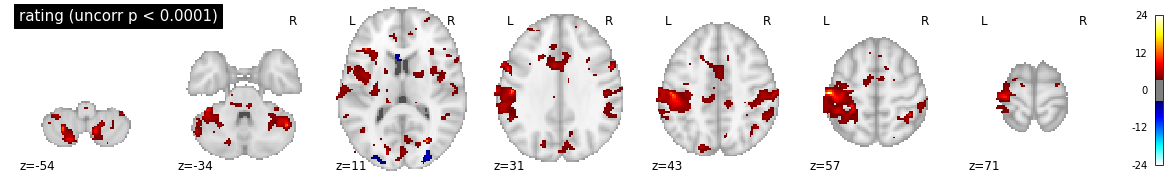

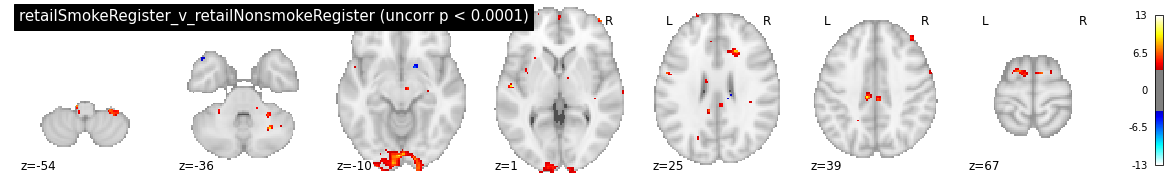

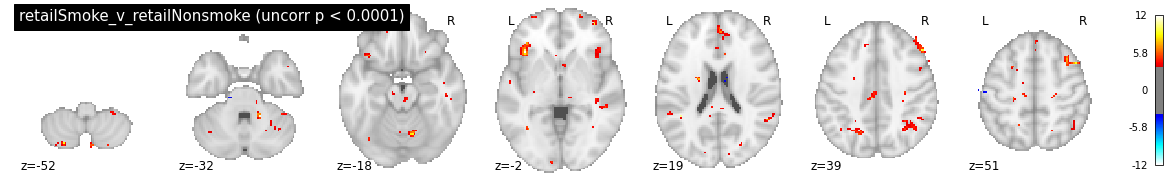

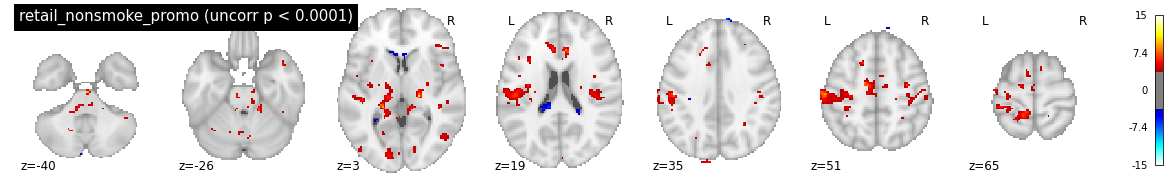

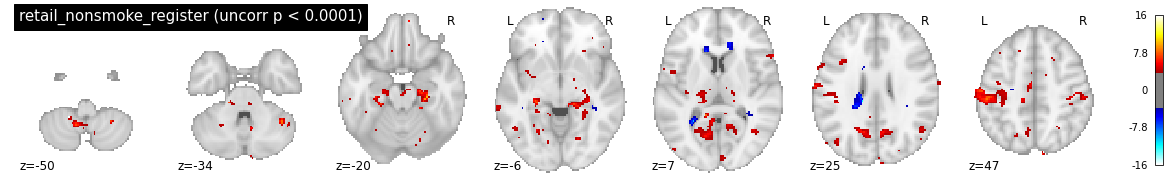

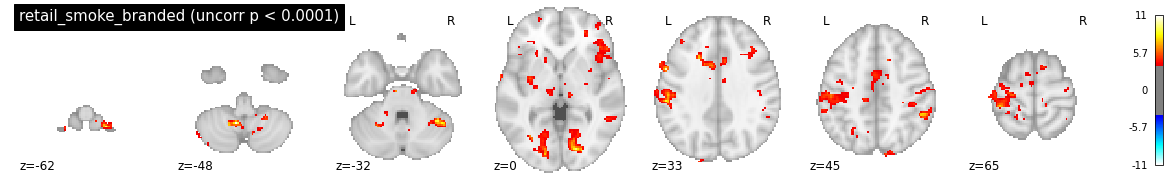

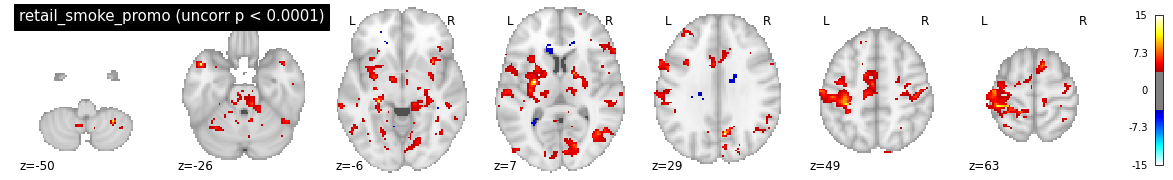

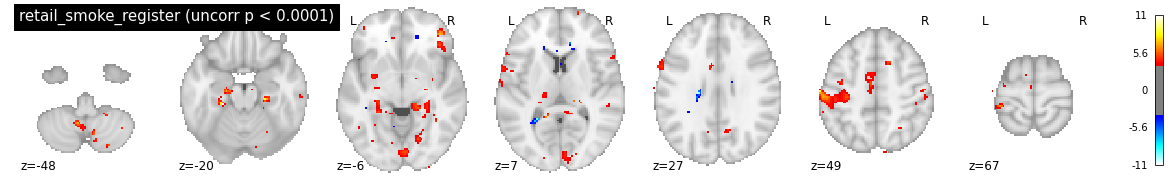

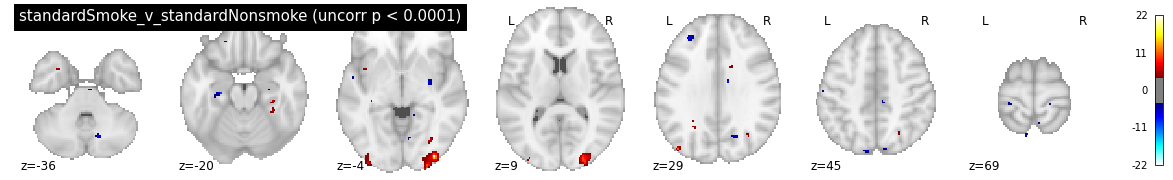

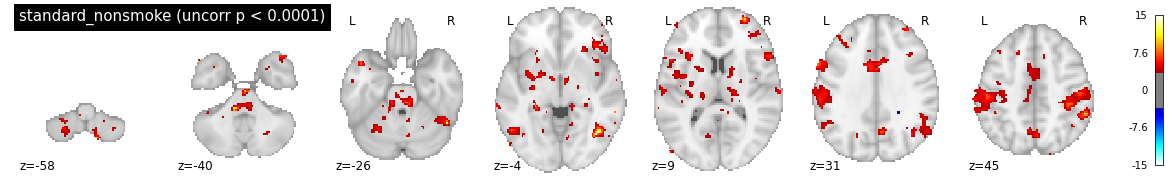

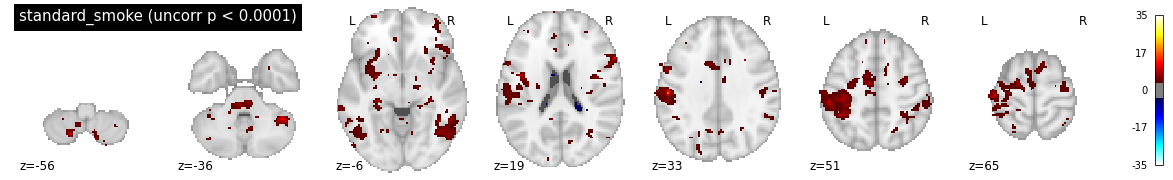

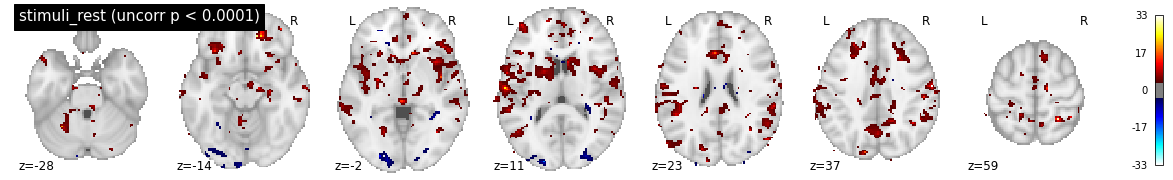

In [11]:
p_val = 0.0001
p001_uncorrected = sp.stats.norm.isf(p_val)

for con_folder in glob.glob(os.path.join(l2analysis_path, "*")):
    if not os.path.isdir(con_folder):
        continue
    
    con_name = os.path.basename(con_folder)
    t_map = os.path.join(con_folder, "spmT_0001.nii")
    
    if not os.path.exists(t_map):
        continue
    
    plotting.plot_stat_map(
        t_map, threshold=p001_uncorrected, colorbar=True, display_mode='z',
        title=f'{con_name} (uncorr p < 0.0001)')
    
    plotting.show()

In [38]:
#!nipypecli crash /fmriMURI/scripts/jupyterhub_users/CNLab/second_level_models/cuereact/crash-20210223-123628-dcosme@asc.upenn.edu-onesampttestdes.a9-d958e803-b1a5-48c7-8126-672179cd7f12.pklz